In [1]:
import numpy as np
from sim_library.simulation import simulate_pulses_p_dist, simulate_pulses_single_atom
from sim_library.sequences import gen_resonant_pm_seq, gen_offresonant_pm_seq, UpPulse, DownPulse, FreeEvolution, PulseSequence
from sim_library.plotting import plot_state_trajectories, plot_bloch
from scipy.constants import hbar, pi
from sim_library.constants import k_eff, dR, m, omega_eg
import matplotlib.pyplot as plt


### NOT Gate

In [4]:
p_min = 0
p_max = 1
basis = np.arange(p_min, p_max + 1)

rabi_freq = 2*pi*10000000
rabi_time = 2*pi/rabi_freq

time_steps = 100

initial_state = np.zeros(shape=len(basis), dtype=np.complex128)
initial_state[0] = 1
initial_state[1] = 0
# initial_state[2] = 1
# initial_state[3] = -1

initial_state = initial_state/ np.linalg.norm(initial_state)

omega_time = 2*pi/omega_eg #chosen to be much larger than recoil shift

print(initial_state)

not_gate = PulseSequence()

freevolve_halfpi = FreeEvolution(laser_det=(np.full(time_steps, omega_eg/2)), duration=omega_time/2) #pi/2
pi_pulse = UpPulse(laser_det=np.full(time_steps, dR), phase=np.full(time_steps, 0), rabi_freq=np.full(time_steps, rabi_freq), duration=rabi_time/2)

not_gate.add_pulses([freevolve_halfpi, pi_pulse, freevolve_halfpi])

wave_func, times = simulate_pulses_single_atom(pulse_seq= not_gate, basis= basis, initial_state=initial_state, d_shift=0)

print(wave_func[-1,:])

print(len(wave_func))



[1.+0.j 0.+0.j]
[-2.18575158e-16+0.00000000e+00j  1.00000000e+00-1.58723343e-05j]
301


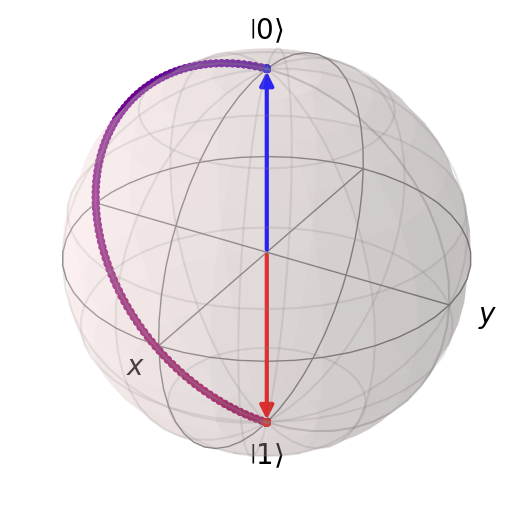

In [5]:

plot_bloch(wave_func=wave_func)

### CP1

In [16]:
# Inverts phase if state = 0

p_min = 0
p_max = 1
basis = np.arange(p_min, p_max + 1)

rabi_freq = 2*pi*10000000
rabi_time = 2*pi/rabi_freq

time_steps = 1

initial_state = np.zeros(shape=len(basis), dtype=np.complex128)
initial_state[0] = 1
initial_state[1] = 1
# initial_state[2] = 1
# initial_state[3] = -1

initial_state = initial_state/ np.linalg.norm(initial_state)

omega_time = 2*pi/omega_eg #chosen to be much larger than recoil shift

print(initial_state)

cpone = PulseSequence()

freevolve_pi = FreeEvolution(laser_det=(np.full(time_steps, omega_eg/2)), duration=omega_time) #pi
twopi_pulse = UpPulse(laser_det=np.full(time_steps, dR), phase=np.full(time_steps, 0), rabi_freq=np.full(time_steps, rabi_freq), duration=rabi_time)

cpone.add_pulses([freevolve_pi, twopi_pulse])

wave_func, times = simulate_pulses_single_atom(pulse_seq= cpone, basis= basis, initial_state=initial_state, d_shift=0)

print(wave_func[-1,:])

[0.70710678+0.j 0.70710678+0.j]
[-0.70710678+1.66260249e-16j  0.70710678-2.24468705e-05j]


### Hadamard

In [38]:
p_min = 0
p_max = 1
basis = np.arange(p_min, p_max + 1)

rabi_freq = 2*pi*10000000
rabi_time = 2*pi/rabi_freq

time_steps = 1

initial_state = np.zeros(shape=len(basis), dtype=np.complex128)
initial_state[0] = 0
initial_state[1] = 1
# initial_state[2] = 1
# initial_state[3] = -1

initial_state = initial_state/ np.linalg.norm(initial_state)

omega_time = 2*pi/omega_eg #chosen to be much larger than recoil shift

print(initial_state)

hadamard = PulseSequence()

freevolve_pi = FreeEvolution(laser_det=(np.full(time_steps, omega_eg/2)), duration=omega_time) #pi
halfpi_pulse = UpPulse(laser_det=np.full(time_steps, dR), phase=np.full(time_steps, pi/2), rabi_freq=np.full(time_steps, rabi_freq), duration=rabi_time/4)
twopi_pulse = UpPulse(laser_det=np.full(time_steps, dR), phase=np.full(time_steps, 0), rabi_freq=np.full(time_steps, rabi_freq), duration=rabi_time)

hadamard.add_pulses([halfpi_pulse, freevolve_pi, twopi_pulse])

wave_func, times = simulate_pulses_single_atom(pulse_seq= hadamard, basis= basis, initial_state=initial_state, d_shift=0)

print(wave_func[-1,:])

[0.+0.j 1.+0.j]
[0.70710678+2.09558052e-16j 0.70710678-2.24468705e-05j]


In [40]:
print(omega_eg)
print(dR)

19074060415.5
96368.27489031358


In [92]:
print(np.exp(1j*pi/2))

(6.123233995736766e-17+1j)
